In [1]:
# Imports and defaults
import joblib
from joblib import Parallel, delayed
import json
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import linprog
import time
import math
import pandas as pd
import scipy.stats as stats
import os
import re

mpl.style.use("classic")
mpl.rcParams["figure.figsize"] = [6, 4]

mpl.rcParams["axes.linewidth"] = 0.75
mpl.rcParams["errorbar.capsize"] = 3
mpl.rcParams["figure.facecolor"] = "w"
mpl.rcParams["grid.linewidth"] = 0.75
mpl.rcParams["lines.linewidth"] = 0.75
mpl.rcParams["patch.linewidth"] = 0.75
mpl.rcParams["xtick.major.size"] = 3
mpl.rcParams["ytick.major.size"] = 3

mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42
mpl.rcParams["font.size"] = 10
mpl.rcParams["axes.titlesize"] = "medium"
mpl.rcParams["legend.fontsize"] = "medium"

import platform
print("python %s" % platform.python_version())
print("matplotlib %s" % mpl.__version__)
print("%d joblib CPUs" % joblib.cpu_count())

def linestyle2dashes(style):
  if style == "--":
    return (3, 3)
  elif style == ":":
    return (0.5, 2.5)
  else:
    return (None, None)

python 3.10.18
matplotlib 3.10.6
24 joblib CPUs


# Main Graphs

In [6]:
# this cell sets files to be a list of every file in newdata except log.txt.

dir_path = './new_data'
files = [f for f in os.listdir(dir_path) if os.path.isfile(os.path.join(dir_path, f))]
files.remove("log.txt")
print(files)

pattern = r"_([^_]+)_"
for text in files:
    match = re.search(pattern, text)
    if match:
        result = match.group(1).capitalize()
        print(result)


['helpsteer2_complexity_gpt-4.1-nano.jsonl', 'helpsteer2_complexity_llama-3-1-8b.jsonl', 'helpsteer2_correctness_gpt-4.1-nano.jsonl', 'helpsteer2_correctness_llama-3-1-8b.jsonl', 'helpsteer2_helpfulness_gpt-4.1-nano.jsonl', 'helpsteer2_helpfulness_llama-3-1-8b.jsonl', 'helpsteer2_verbosity_gpt-4.1-nano.jsonl', 'helpsteer2_verbosity_llama-3-1-8b.jsonl']
Complexity
Complexity
Correctness
Correctness
Helpfulness
Helpfulness
Verbosity
Verbosity


Number of arms: 1017
Percentage of invalid rewards: 0.57%


C:\Users\anike\AppData\Local\Temp\ipykernel_18652\4114886691.py:27: RuntimeWarning: Mean of empty slice.
  mu[i] = sub_rewards.mean()


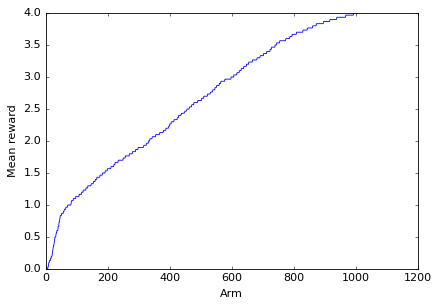

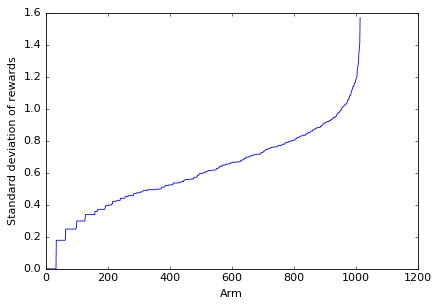

Running Uniform...
..................................................Running ROBIN...
..................................................Running ROBIN-HOOD...
..................................................Delta: 0.007, Runs: 50, Steps: 100000, Burn-in-period: 20145.091227502904


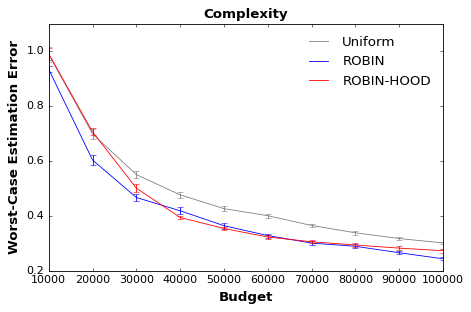

Number of arms: 1017
Percentage of invalid rewards: 0.03%


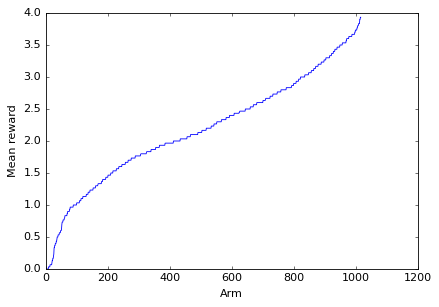

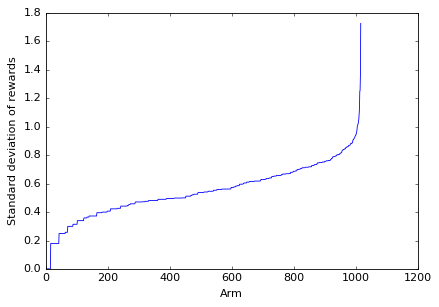

Running Uniform...
..................................................Running ROBIN...
..................................................Running ROBIN-HOOD...
..................................................Delta: 0.007, Runs: 50, Steps: 100000, Burn-in-period: 20184.785988542317


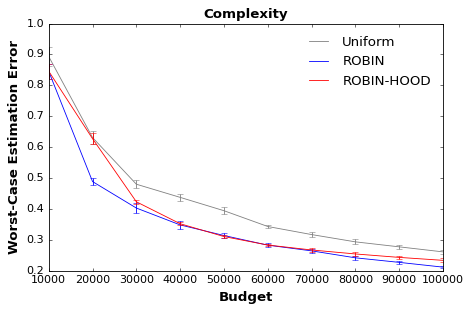

Number of arms: 1017
Percentage of invalid rewards: 0.61%


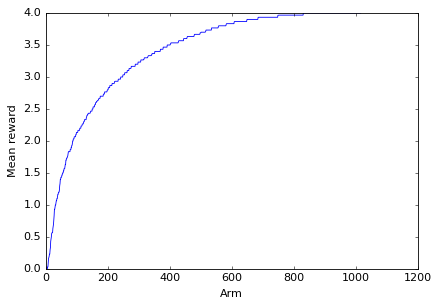

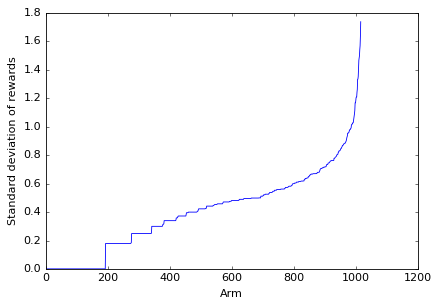

Running Uniform...
..................................................Running ROBIN...
..................................................Running ROBIN-HOOD...
..................................................Delta: 0.007, Runs: 50, Steps: 100000, Burn-in-period: 20184.785988542317


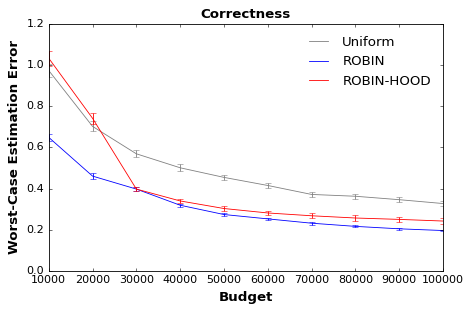

Number of arms: 1017
Percentage of invalid rewards: 0.01%


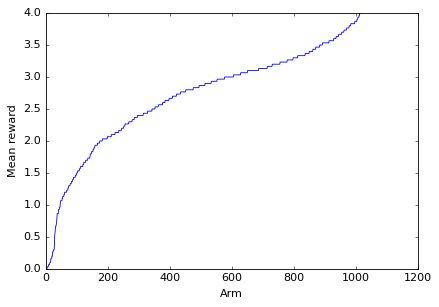

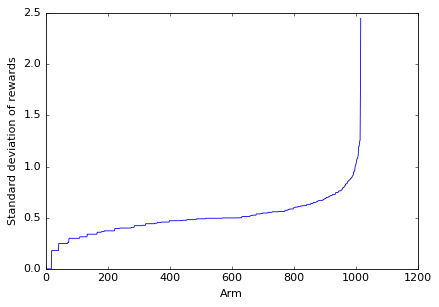

Running Uniform...
..................................................Running ROBIN...
..................................................Running ROBIN-HOOD...
..................................................Delta: 0.007, Runs: 50, Steps: 100000, Burn-in-period: 20184.785988542317


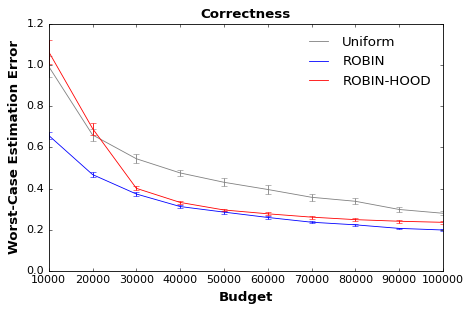

Number of arms: 1017
Percentage of invalid rewards: 0.70%


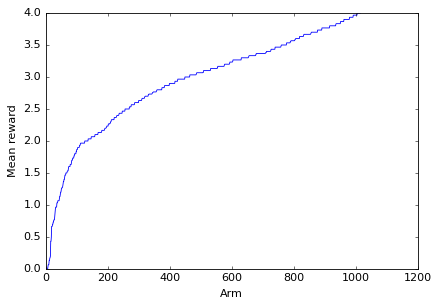

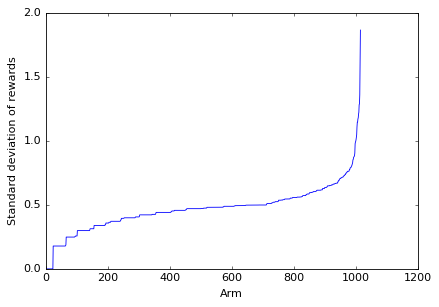

Running Uniform...
..................................................Running ROBIN...
..................................................Running ROBIN-HOOD...
..................................................Delta: 0.007, Runs: 50, Steps: 100000, Burn-in-period: 20164.93860802261


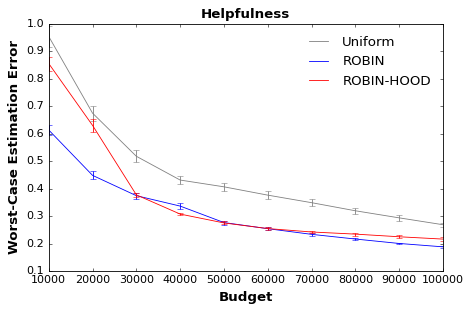

Number of arms: 1017
Percentage of invalid rewards: 0.00%


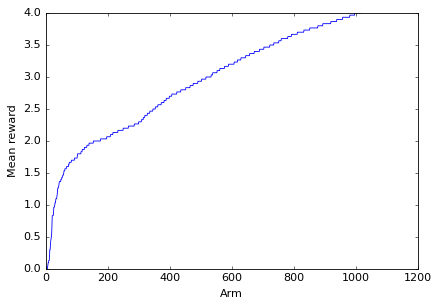

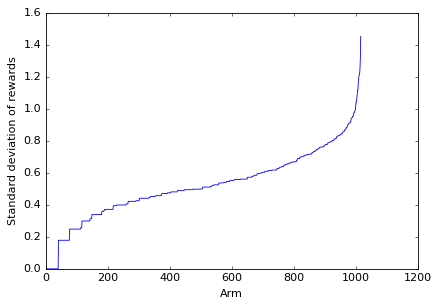

Running Uniform...
..................................................Running ROBIN...
..................................................Running ROBIN-HOOD...
..................................................Delta: 0.007, Runs: 50, Steps: 100000, Burn-in-period: 20184.785988542317


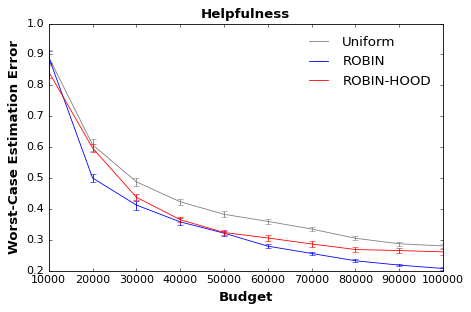

Number of arms: 1017
Percentage of invalid rewards: 0.36%


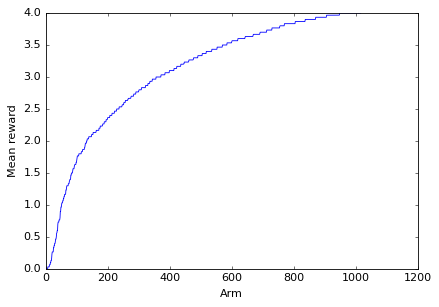

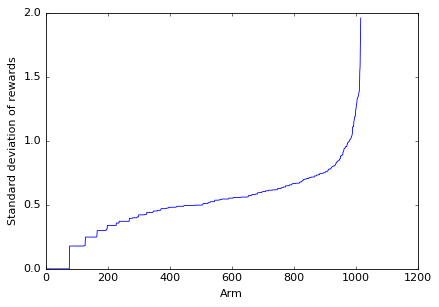

Running Uniform...
..................................................Running ROBIN...
..................................................Running ROBIN-HOOD...
..................................................Delta: 0.007, Runs: 50, Steps: 100000, Burn-in-period: 20184.785988542317


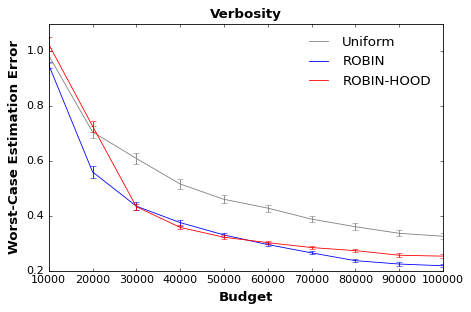

Number of arms: 1017
Percentage of invalid rewards: 0.05%


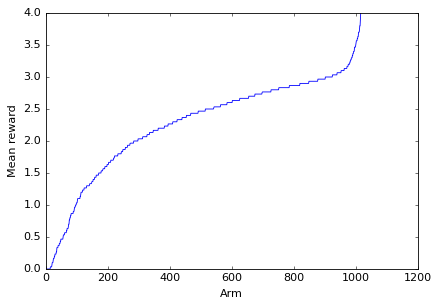

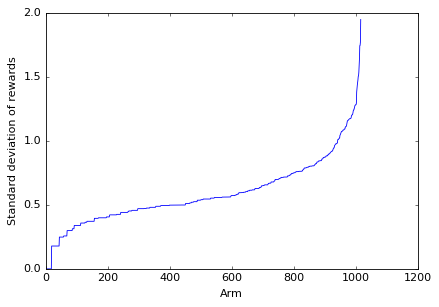

Running Uniform...
..................................................Running ROBIN...
..................................................Running ROBIN-HOOD...
..................................................Delta: 0.007, Runs: 50, Steps: 100000, Burn-in-period: 20184.785988542317


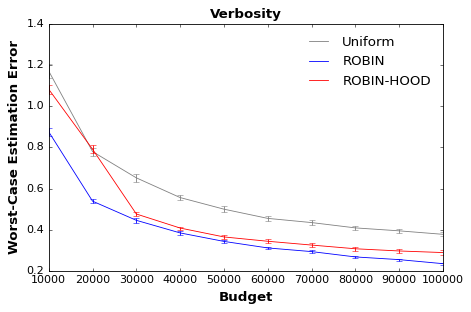

In [7]:
# files = ["helpsteer2_helpfulness_gpt-4.1-nano.jsonl"]

exp_1_version = "v1.01"
for actual_filename in files:
    filename = f"new_data/{actual_filename[:-6]}"
    # filename = "new_data/helpsteer2_helpfulness_gpt-4.1-nano"

    with open("%s.jsonl" % filename, "r") as f:
      data = f.readlines()
    data = [json.loads(_) for _ in data]

    per_arm_rewards = 30  # number of per-arm random rewards
    K = len(data) // per_arm_rewards  # number of arms
    print("Number of arms: %d" % K)

    rewards = np.asarray([_["predicted_score"] for _ in data], dtype=float)
    print("Percentage of invalid rewards: %.2f%%" % (100 * (rewards == -1).mean()))

    random_rewards = {}
    mu = np.zeros(K)
    sigma = np.zeros(K)
    new_K = 0
    for i in range(K):
      sub_rewards = rewards[i * per_arm_rewards : (i + 1) * per_arm_rewards]
      sub_rewards = sub_rewards[sub_rewards >= 0]  # eliminate invalid rewards
      random_rewards[i] = sub_rewards
      mu[i] = sub_rewards.mean()
      sigma[i] = np.maximum(sub_rewards.std(), 1e-3)
      if len(sub_rewards) == 0:
        new_K -= 1

    new_K = new_K + K
    new_random_rewards = {}
    new_mu = []
    new_sigma = []

    true_counter = 0
    for i in range(K):
      if len(random_rewards[i]) != 0:
        new_random_rewards[true_counter] = random_rewards[i]
        new_mu.append(mu[i])
        new_sigma.append(sigma[i])
        true_counter += 1

    K = new_K
    random_rewards = new_random_rewards
    mu = np.array(new_mu)
    sigma = np.array(new_sigma)

    plt.plot(np.sort(mu))
    plt.xlabel("Arm")
    plt.ylabel("Mean reward")
    plt.show()

    plt.plot(np.sort(sigma))
    plt.xlabel("Arm")
    plt.ylabel("Standard deviation of rewards")
    plt.show()

    n = 100000  # number of logged steps
    num_runs = 50  # number of runs

    # algorithms
    algs = [
      (0, "Uniform", "gray", "Uniform"),
      (1, "ROBIN", "blue", "ROBIN"),
      (2, "ROBIN-HOOD", "red", "ROBIN-HOOD")]

    # deltas = [0.49, 0.25, 0.125, 0.0625, 0.03125, 0.015625, 0.0078125, 0.00390625]
    deltas = [0.007]

    # plt.figure(figsize=(6, 3))
    for delta in deltas:
        for alg in algs:
          alg_name = alg[1]
          print("Running %s..." % alg_name)

          # initialize reward variances
          if alg_name == "Uniform":
            sigma2 = np.ones(K)
          elif alg_name == "ROBIN":
            sigma2 = np.square(sigma)
          elif alg_name == "ROBIN-HOOD":
            sigma2 = - np.ones(K)
          else:
            raise Exception("Unknown algorithm!")

          steps = np.arange(n // 10, n + 1, n // 10)
          errors = np.zeros((steps.size, num_runs))
          for run in range(num_runs):
            print(".", end="")

            # bandit algorithm statistics
            # delta = 0.01
            pulls = np.zeros(K)  # number of pulls
            sum_reward = np.zeros(K)  # sum of rewards of pulled arms
            sum_reward2 = np.zeros(K)  # sum of squared rewards of pulled arms

            # data logging
            logged_arms = np.zeros(n)  # logged arms
            logged_rewards = np.zeros(n)  # logged rewards
            for t in range(n):
              # pull arm
              if (alg_name == "ROBIN-HOOD") and (np.floor(t / K) <= 4 * np.log(1 / delta)): # Required condition for running UCB.
                arm = t % K
              else:
                ucb = sigma2 / np.maximum(pulls, 1e-6)
                arm = np.argmax(ucb)

              # observe random reward
              try:
                r = random_rewards[arm][np.random.randint(random_rewards[arm].size)]
              except:
                print("arm: ",arm)
                raise

              # logging
              logged_arms[t] = arm
              logged_rewards[t] = r

              # update statistics
              pulls[arm] += 1
              sum_reward[arm] += r
              sum_reward2[arm] += r * r
              if (alg_name == "ROBIN-HOOD") and (np.floor(t / K) > 4 * np.log(1 / delta)):
                mu_hat = sum_reward / pulls
                var_hat = (sum_reward2 - 2 * sum_reward * mu_hat + pulls * np.square(mu_hat)) / (pulls - 1)
                sigma2 = var_hat / (1 - 2 * np.sqrt(np.log(1 / delta) / pulls))

            # estimate mean arm rewards from logged data
            for ndx, t in enumerate(steps):
              mu_hat = np.zeros(K)
              for i in range(K):
                sub = np.logical_and(logged_arms == i, np.arange(n) < t) # times arm i was chosen as an array.
                mu_hat[i] = logged_rewards[sub].sum() / np.sum(sub)
              errors[ndx, run] = np.abs(mu - mu_hat).max()
          # print(errors)
          plt.plot(steps, errors.mean(axis=-1), color=alg[2], label=alg[3])
          plt.errorbar(steps, errors.mean(axis=-1), errors.std(axis=-1) / np.sqrt(num_runs),
            fmt="none", ecolor=alg[2])

        print(f"Delta: {delta}, Runs: {num_runs}, Steps: {n}, Burn-in-period: {math.log(1/delta)*4*K}")

        pattern = r"_([^_]+)_"
        match = re.search(pattern, actual_filename)
        title = match.group(1).capitalize()
        plt.title(title, fontsize=12, fontweight="bold")
        plt.xlabel("Budget", fontsize=12, fontweight="bold")
        plt.ylabel("Worst-Case Estimation Error", fontsize=12, fontweight="bold")
        plt.legend(frameon=False, fontsize=12)

        # print(np.arange(steps[0], n+1, n//5))
        # plt.xticks(np.arange(steps[0], n+1, n//5), fontsize=11)
        # plt.xticks(fontsize=12)
        # plt.yticks(fontsize=12)

        plt.tight_layout()
        plt.savefig(f"./outputs/exp1/proper_versioning/{exp_1_version},file= {filename[9:]}, runs averaged= {num_runs}, steps= {n}, delta={delta:.3f}, burn_in_period= {math.log(1/delta)*4*K}, max-error.pdf", format="pdf", dpi=1200, bbox_inches=0)
        plt.show()

# Experiment 2 Data generation


In [2]:
filename = "new_data/helpsteer2_helpfulness_gpt-4.1-nano"


with open("%s.jsonl" % filename, "r") as f:
  data = f.readlines()
data = [json.loads(_) for _ in data]

per_arm_rewards = 30  # number of per-arm random rewards
K = len(data) // per_arm_rewards  # number of arms

n = 100000  # number of logged steps
num_runs = 50  # number of runs


delta = 0.007

experiments_2_df = pd.DataFrame(columns=["model", "attribute_being_scored", "50k_Uniform", "50k_UCB", "50k_Variance", "50k_Uniform_std_deviation", "50k_UCB_std_deviation", "50k_Variance_std_deviation", "50k_Uniform_+-error_bar", "50k_UCB_+-error_bar", "50k_Variance_+-error_bar", "100k_Uniform", "100k_UCB", "100k_Variance", "100k_Uniform_std_deviation", "100k_UCB_std_deviation", "100k_Variance_std_deviation", "100k_Uniform_+-error_bar", "100k_UCB_+-error_bar", "100k_Variance_+-error_bar"])
experiments_2_df.attrs = {"runs_average" : num_runs, "prompt-response pairs" : K, "delta" : delta, "logged_steps" : n ,"burn_in_period" : math.log(1/delta,2)*4*K}


models = ["llama-3-1-8b","gpt-4.1-nano"]
data_attributes = ["complexity", "correctness", "helpfulness", "verbosity"]
# models = ["llama-3-1-8b"]
# data_attributes = ["complexity"]
for attribute in data_attributes:
    for model in models:
        filename = f"new_data/helpsteer2_{attribute}_{model}"
        print(filename)

        with open("%s.jsonl" % filename, "r") as f:
          data = f.readlines()
        data = [json.loads(_) for _ in data]

        per_arm_rewards = 30  # number of per-arm random rewards
        K = len(data) // per_arm_rewards  # number of arms
        print("Number of arms: %d" % K)

        rewards = np.asarray([_["predicted_score"] for _ in data], dtype=float)
        print("Percentage of invalid rewards: %.2f%%" % (100 * (rewards == -1).mean()))

        random_rewards = {}
        mu = np.zeros(K)
        sigma = np.zeros(K)
        new_K = 0
        for i in range(K):
          sub_rewards = rewards[i * per_arm_rewards : (i + 1) * per_arm_rewards]
          sub_rewards = sub_rewards[sub_rewards >= 0]  # eliminate invalid rewards
          random_rewards[i] = sub_rewards
          mu[i] = sub_rewards.mean()
          sigma[i] = np.maximum(sub_rewards.std(), 1e-3)
          if len(sub_rewards) == 0:
            new_K -= 1

        new_K = new_K + K
        new_random_rewards = {}
        new_mu = []
        new_sigma = []

        true_counter = 0
        for i in range(K):
          if len(random_rewards[i]) != 0:
            new_random_rewards[true_counter] = random_rewards[i]
            new_mu.append(mu[i])
            new_sigma.append(sigma[i])
            true_counter += 1

        K = new_K
        random_rewards = new_random_rewards
        mu = np.array(new_mu)
        sigma = np.array(new_sigma)

        # algorithms
        algs = [
          (0, "Uniform", "gray", "Uniform"),
          (1, "Variance", "blue", "Variance"),
          (2, "UCB", "red", "UCB")]

        algo_final_errors = {"UCB": -1, "Uniform": -1, "Variance": -1}

        new_row = {'model' : model, 'attribute_being_scored' : attribute, "UCB" : -2, "Variance" : -3, "Uniform" : -4}
        for alg in algs:

          alg_name = alg[1]
          print("Running %s..." % alg_name)

          # initialize reward variances
          if alg_name == "Uniform":
            sigma2 = np.ones(K)
          elif alg_name == "Variance":
            sigma2 = np.square(sigma)
          elif alg_name == "UCB":
            sigma2 = - np.ones(K)
          else:
            raise Exception("Unknown algorithm!")

          # steps = np.arange(n // 10, n + 1, n // 10) # This
          steps = np.array([50000,100000]) # This
          errors = np.zeros((steps.size, num_runs))
          for run in range(num_runs):
            print(".", end="")

            # bandit algorithm statistics
            # delta = 0.01
            pulls = np.zeros(K)  # number of pulls
            sum_reward = np.zeros(K)  # sum of rewards of pulled arms
            sum_reward2 = np.zeros(K)  # sum of squared rewards of pulled arms

            # data logging
            logged_arms = np.zeros(n)  # logged arms
            logged_rewards = np.zeros(n)  # logged rewards
            for t in range(n):
              # pull arm
              if (alg_name == "UCB") and (np.floor(t / K) <= 4 * np.log(1 / delta)): # Required condition for running UCB.
                arm = t % K
              else:
                ucb = sigma2 / np.maximum(pulls, 1e-6)
                arm = np.argmax(ucb)

              # observe random reward
              try:
                r = random_rewards[arm][np.random.randint(random_rewards[arm].size)]
              except:
                print("arm: ",arm)
                raise

              # logging
              logged_arms[t] = arm
              logged_rewards[t] = r

              # update statistics
              pulls[arm] += 1
              sum_reward[arm] += r
              sum_reward2[arm] += r * r
              if (alg_name == "UCB") and (np.floor(t / K) > 4 * np.log(1 / delta)):
                mu_hat = sum_reward / pulls
                var_hat = (sum_reward2 - 2 * sum_reward * mu_hat + pulls * np.square(mu_hat)) / (pulls - 1)
                sigma2 = var_hat / (1 - 2 * np.sqrt(np.log(1 / delta) / pulls))

            # estimate mean arm rewards from logged data
            for ndx, t in enumerate(steps):
              mu_hat = np.zeros(K)
              for i in range(K):
                sub = np.logical_and(logged_arms == i, np.arange(n) < t) # times arm i was chosen as an array.
                mu_hat[i] = logged_rewards[sub].sum() / np.sum(sub)
              errors[ndx, run] = np.abs(mu - mu_hat).max()
          # print(f"errors[0]: {errors[0]}, errors[1]: {errors[1]}")
          # print(f"errors[0].mean(): {errors[0].mean()}, errors[1].mean(): {errors[1].mean()}")
          new_row[f"50k_{alg_name}"] = np.round(errors[0].mean(),3)
          new_row[f"50k_{alg_name}_std_deviation"] = np.round(errors[0].std(),3)
          new_row[f"50k_{alg_name}_+-error_bar"] = np.round(errors[0].std()/np.sqrt(num_runs),3)
          new_row[f"100k_{alg_name}"] = np.round(errors[1].mean(),3)
          new_row[f"100k_{alg_name}_std_deviation"] = np.round(errors[1].std(),3)
          new_row[f"100k_{alg_name}_+-error_bar"] = np.round(errors[1].std()/np.sqrt(num_runs),3)
        experiments_2_df.loc[len(experiments_2_df)] = new_row

name_to_save  = f"error_bars_runs_average{experiments_2_df.attrs['runs_average']},prompt-response pairs{experiments_2_df.attrs['prompt-response pairs']},delta{experiments_2_df.attrs['delta']},logged_steps{experiments_2_df.attrs['logged_steps']},burn_in_period{experiments_2_df.attrs['burn_in_period']}"

# {"runs_average" : num_runs, "prompt-response pairs" : K, "delta" : delta, "logged_steps" : n ,"burn_in_period" : math.log(1/delta,2)*4*K}
print("\n", name_to_save)

with open(f"outputs/exp2/{name_to_save}.json", 'w') as f:
    json.dump(experiments_2_df.attrs, f)
experiments_2_df.to_csv(f"outputs/exp2/{name_to_save}.csv", index=False)

new_data/helpsteer2_complexity_llama-3-1-8b
Number of arms: 1017
Percentage of invalid rewards: 0.03%
Running Uniform...
..................................................Running Variance...
..................................................Running UCB...
..................................................new_data/helpsteer2_complexity_gpt-4.1-nano
Number of arms: 1017
Percentage of invalid rewards: 0.57%
Running Uniform...
.

C:\Users\anike\AppData\Local\Temp\ipykernel_34100\3962022221.py:49: RuntimeWarning: Mean of empty slice.
  mu[i] = sub_rewards.mean()
C:\Users\anike\.conda\envs\torch\lib\site-packages\numpy\_core\_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\anike\.conda\envs\torch\lib\site-packages\numpy\_core\_methods.py:227: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\anike\.conda\envs\torch\lib\site-packages\numpy\_core\_methods.py:184: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
C:\Users\anike\.conda\envs\torch\lib\site-packages\numpy\_core\_methods.py:219: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


.................................................Running Variance...
..................................................Running UCB...
..................................................new_data/helpsteer2_correctness_llama-3-1-8b
Number of arms: 1017
Percentage of invalid rewards: 0.01%
Running Uniform...
..................................................Running Variance...
..................................................Running UCB...
..................................................new_data/helpsteer2_correctness_gpt-4.1-nano
Number of arms: 1017
Percentage of invalid rewards: 0.61%
Running Uniform...
..................................................Running Variance...
..................................................Running UCB...
..................................................new_data/helpsteer2_helpfulness_llama-3-1-8b
Number of arms: 1017
Percentage of invalid rewards: 0.00%
Running Uniform...
..................................................Running Variance...
..........

C:\Users\anike\AppData\Local\Temp\ipykernel_34100\3962022221.py:49: RuntimeWarning: Mean of empty slice.
  mu[i] = sub_rewards.mean()
C:\Users\anike\.conda\envs\torch\lib\site-packages\numpy\_core\_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\anike\.conda\envs\torch\lib\site-packages\numpy\_core\_methods.py:227: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\anike\.conda\envs\torch\lib\site-packages\numpy\_core\_methods.py:184: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
C:\Users\anike\.conda\envs\torch\lib\site-packages\numpy\_core\_methods.py:219: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


.................................................Running Variance...
..................................................Running UCB...
..................................................new_data/helpsteer2_verbosity_llama-3-1-8b
Number of arms: 1017
Percentage of invalid rewards: 0.05%
Running Uniform...
..................................................Running Variance...
..................................................Running UCB...
..................................................new_data/helpsteer2_verbosity_gpt-4.1-nano
Number of arms: 1017
Percentage of invalid rewards: 0.36%
Running Uniform...
..................................................Running Variance...
..................................................Running UCB...
..................................................
 error_bars_runs_average50,prompt-response pairs1017,delta0.007,logged_steps100000,burn_in_period29120.490647075036


In [3]:
to_be_shown = pd.read_csv("outputs/exp2/error_bars_runs_average50,prompt-response pairs1017,delta0.007,logged_steps100000,burn_in_period29120.490647075036.csv")



to_be_shown = to_be_shown[["model","attribute_being_scored", "50k_Uniform", "50k_UCB", "50k_Variance", "50k_Uniform_+-error_bar", "50k_UCB_+-error_bar", "50k_Variance_+-error_bar", "100k_Uniform", "100k_UCB", "100k_Variance", "100k_Uniform_+-error_bar", "100k_UCB_+-error_bar", "100k_Variance_+-error_bar"]]

actual_table = pd.DataFrame(columns=["model","attribute_being_scored", "50k_Uniform", "50k_UCB", "50k_Variance", "100k_Uniform", "100k_UCB", "100k_Variance"])


value_cols = [
    "50k_Uniform", "50k_UCB", "50k_Variance",
    "100k_Uniform", "100k_UCB", "100k_Variance"
]
error_bar_cols = [
    "50k_Uniform_+-error_bar", "50k_UCB_+-error_bar", "50k_Variance_+-error_bar",
    "100k_Uniform_+-error_bar", "100k_UCB_+-error_bar", "100k_Variance_+-error_bar"
]

for idx, row in to_be_shown.iterrows():
    # Build new row dict, keeping the structure of actual_table
    new_row = {
        "model": row["model"],
        "attribute_being_scored": row["attribute_being_scored"]
    }
    for val_col, err_col in zip(value_cols, error_bar_cols):
        val = row[val_col]
        err = row[err_col]
        # Format as float ± error, both with 4 decimals
        new_row[val_col] = f"{val:.3f} ± {err:.3f}"
    # Add new row to actual_table

    actual_table.loc[len(actual_table)] = new_row
    # actual_table = actual_table.append(new_row, ignore_index=True)


actual_table.to_csv(f"outputs/exp2/exp2 final 007.csv", index=False)

# Experiment 3

new_data/helpsteer2_complexity_llama-3-1-8b
Number of arms: 1017
Percentage of invalid rewards: 0.03%
Running UCB...
Steps: [  1017  10000  20000  30000  40000  50000  60000  70000  80000  90000
 100000]
..................................................Delta: 0.007, Runs: 50, Steps: 100000, Burn-in-period: 20184.785988542317


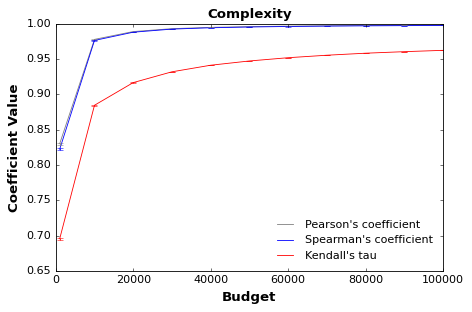

new_data/helpsteer2_complexity_gpt-4.1-nano
Number of arms: 1017
Percentage of invalid rewards: 0.57%
Running UCB...
Steps: [  1015  10000  20000  30000  40000  50000  60000  70000  80000  90000
 100000]
.

C:\Users\anike\AppData\Local\Temp\ipykernel_10180\3492336676.py:41: RuntimeWarning: Mean of empty slice.
  mu[i] = sub_rewards.mean()


.................................................Delta: 0.007, Runs: 50, Steps: 100000, Burn-in-period: 20145.091227502904


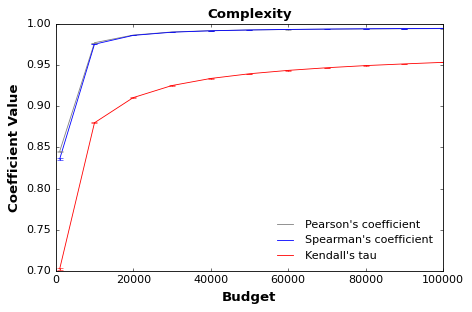

new_data/helpsteer2_correctness_llama-3-1-8b
Number of arms: 1017
Percentage of invalid rewards: 0.01%
Running UCB...
Steps: [  1017  10000  20000  30000  40000  50000  60000  70000  80000  90000
 100000]
..................................................Delta: 0.007, Runs: 50, Steps: 100000, Burn-in-period: 20184.785988542317


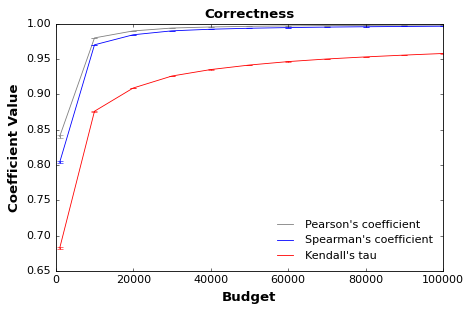

new_data/helpsteer2_correctness_gpt-4.1-nano
Number of arms: 1017
Percentage of invalid rewards: 0.61%
Running UCB...
Steps: [  1017  10000  20000  30000  40000  50000  60000  70000  80000  90000
 100000]
..................................................Delta: 0.007, Runs: 50, Steps: 100000, Burn-in-period: 20184.785988542317


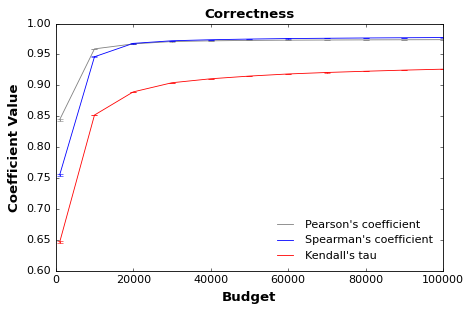

new_data/helpsteer2_helpfulness_llama-3-1-8b
Number of arms: 1017
Percentage of invalid rewards: 0.00%
Running UCB...
Steps: [  1017  10000  20000  30000  40000  50000  60000  70000  80000  90000
 100000]
..................................................Delta: 0.007, Runs: 50, Steps: 100000, Burn-in-period: 20184.785988542317


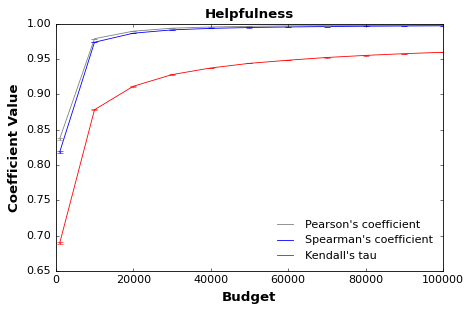

new_data/helpsteer2_helpfulness_gpt-4.1-nano
Number of arms: 1017
Percentage of invalid rewards: 0.70%
Running UCB...
Steps: [  1016  10000  20000  30000  40000  50000  60000  70000  80000  90000
 100000]
..................................................Delta: 0.007, Runs: 50, Steps: 100000, Burn-in-period: 20164.93860802261


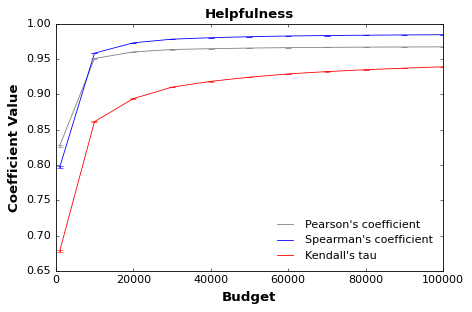

new_data/helpsteer2_verbosity_llama-3-1-8b
Number of arms: 1017
Percentage of invalid rewards: 0.05%
Running UCB...
Steps: [  1017  10000  20000  30000  40000  50000  60000  70000  80000  90000
 100000]
..................................................Delta: 0.007, Runs: 50, Steps: 100000, Burn-in-period: 20184.785988542317


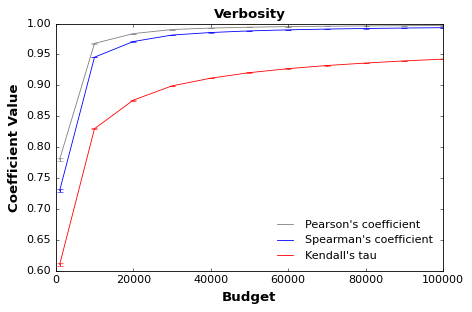

new_data/helpsteer2_verbosity_gpt-4.1-nano
Number of arms: 1017
Percentage of invalid rewards: 0.36%
Running UCB...
Steps: [  1017  10000  20000  30000  40000  50000  60000  70000  80000  90000
 100000]
..................................................Delta: 0.007, Runs: 50, Steps: 100000, Burn-in-period: 20184.785988542317


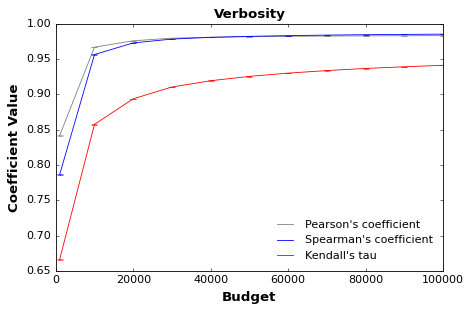

In [23]:
n = 100000  # number of logged steps
num_runs = 50  # number of runs

delta = 0.007



models = ["llama-3-1-8b","gpt-4.1-nano"]
data_attributes = ["complexity", "correctness", "helpfulness", "verbosity"]
# attribute = "helpfulness"

for attribute in data_attributes:
    for model in models:
        # plt.figure(figsize=(4, 3))
        filename = f"new_data/helpsteer2_{attribute}_{model}"
        print(filename)

        with open("%s.jsonl" % filename, "r") as f:
          data = f.readlines()
        data = [json.loads(_) for _ in data]

        per_arm_rewards = 30  # number of per-arm random rewards
        K = len(data) // per_arm_rewards  # number of arms
        print("Number of arms: %d" % K)

        rewards = np.asarray([_["predicted_score"] for _ in data], dtype=float) # Need one more array for human rewards as well.
        human_rewards = np.asarray([_["predicted_score"] for _ in data], dtype=float)
        print("Percentage of invalid rewards: %.2f%%" % (100 * (rewards == -1).mean()))

        random_rewards = {}
        human_score = {}
        human_mu = np.zeros(K)
        mu = np.zeros(K)
        sigma = np.zeros(K)
        new_K = 0
        for i in range(K):
          sub_rewards = rewards[i * per_arm_rewards : (i + 1) * per_arm_rewards]
          sub_rewards = sub_rewards[sub_rewards >= 0]  # eliminate invalid rewards
          random_rewards[i] = sub_rewards
          sub_human_rewards = human_rewards[i * per_arm_rewards : (i + 1) * per_arm_rewards]
          mu[i] = sub_rewards.mean()
          human_mu[i] = sub_human_rewards.mean()
          sigma[i] = np.maximum(sub_rewards.std(), 1e-3)
          if len(sub_rewards) == 0:
            new_K -= 1

        new_K = new_K + K
        new_random_rewards = {}
        new_mu = []
        new_human_mu = []
        new_sigma = []

        true_counter = 0
        for i in range(K):
          if len(random_rewards[i]) != 0:
            new_random_rewards[true_counter] = random_rewards[i]
            new_mu.append(mu[i])
            new_human_mu.append(human_mu[i])
            new_sigma.append(sigma[i])
            true_counter += 1

        K = new_K
        random_rewards = new_random_rewards
        mu = np.array(new_mu)
        human_mu = np.array(new_human_mu)
        sigma = np.array(new_sigma)

        # algorithms

        # algs = [
        #   (0, "Uniform", "gray", "Uniform"),
        #   (1, "Variance", "blue", "Variance"),
        #   (2, "UCB", "red", "UCB")]
        alg = (2, "UCB", "red", "UCB")
        # for alg in algs:

        alg_name = alg[1]
        print("Running %s..." % alg_name)

        # initialize reward variances
        if alg_name == "Uniform":
          sigma2 = np.ones(K)
        elif alg_name == "Variance":
          sigma2 = np.square(sigma)
        elif alg_name == "UCB":
          sigma2 = - np.ones(K)
        else:
          raise Exception("Unknown algorithm!")

        steps = np.arange(n // 10, n + 1, n // 10)
        steps = np.insert(steps, 0, K)
        print("Steps:", steps)

        pearsons_coefficients = np.zeros((steps.size, num_runs))
        spearman_coefficients = np.zeros((steps.size, num_runs))
        kendall_coefficients = np.zeros((steps.size, num_runs))

        new_row = {"Model/Algorithm": f"{model}-{alg_name}","Pearson_coefficient": -1, "Spearman_coefficient": -1, "kendall_tau": -1}

        for run in range(num_runs):
          print(".", end="")

          # bandit algorithm statistics
          # delta = 0.01
          pulls = np.zeros(K)  # number of pulls
          sum_reward = np.zeros(K)  # sum of rewards of pulled arms
          sum_reward2 = np.zeros(K)  # sum of squared rewards of pulled arms

          # data logging
          logged_arms = np.zeros(n)  # logged arms
          logged_rewards = np.zeros(n)  # logged rewards
          for t in range(n):
            # pull arm
            if (alg_name == "UCB") and (np.floor(t / K) <= 4 * np.log(1 / delta)): # Required condition for running UCB.
              arm = t % K
            else:
              ucb = sigma2 / np.maximum(pulls, 1e-6)
              arm = np.argmax(ucb)

            # observe random reward
            try:
              r = random_rewards[arm][np.random.randint(random_rewards[arm].size)]
            except:
              print("arm: ",arm)
              raise

            # logging
            logged_arms[t] = arm
            logged_rewards[t] = r

            # update statistics
            pulls[arm] += 1
            sum_reward[arm] += r
            sum_reward2[arm] += r * r
            if (alg_name == "UCB") and (np.floor(t / K) > 4 * np.log(1 / delta)):
              mu_hat = sum_reward / pulls
              var_hat = (sum_reward2 - 2 * sum_reward * mu_hat + pulls * np.square(mu_hat)) / (pulls - 1)
              sigma2 = var_hat / (1 - 2 * np.sqrt(np.log(1 / delta) / pulls))

          # estimate mean arm rewards from logged data
          # I'll need to keep track the coefficients and track how they decrease with sample size.


          for ndx, t in enumerate(steps):
            mu_hat = np.zeros(K)
            for i in range(K):
              sub = np.logical_and(logged_arms == i, np.arange(n) < t) # times arm i was chosen as an array.
              mu_hat[i] = logged_rewards[sub].sum() / np.sum(sub)
            # errors[ndx, run] = np.abs(mu - mu_hat).max()
            pearsons_coefficients[ndx, run] = stats.pearsonr(mu_hat, human_mu).statistic
            spearman_coefficients[ndx, run] = stats.spearmanr(mu_hat, human_mu).statistic
            kendall_coefficients[ndx, run] = stats.kendalltau(mu_hat, human_mu).statistic
            # print(f"Step {t}: pearsons_coefficients = {pearsons_coefficients}")


        # algs = [
        #   (0, "Uniform", "gray", "Uniform"),
        #   (1, "Variance", "blue", "Variance"),
        #   (2, "UCB", "red", "UCB")]
        plt.plot(steps, pearsons_coefficients.mean(axis=-1), color="gray", label="Pearson's coefficient")
        plt.plot(steps, spearman_coefficients.mean(axis=-1), color="blue", label="Spearman's coefficient")
        plt.plot(steps, kendall_coefficients.mean(axis=-1), color="red", label="Kendall's tau")

        plt.errorbar(steps, pearsons_coefficients.mean(axis=-1), pearsons_coefficients.std(axis=-1) / np.sqrt(num_runs),
          fmt="none", ecolor="gray")
        plt.errorbar(steps, spearman_coefficients.mean(axis=-1), spearman_coefficients.std(axis=-1) / np.sqrt(num_runs),
          fmt="none", ecolor="blue")
        plt.errorbar(steps, kendall_coefficients.mean(axis=-1), kendall_coefficients.std(axis=-1) / np.sqrt(num_runs),
          fmt="none", ecolor="red")

        print(f"Delta: {delta}, Runs: {num_runs}, Steps: {n}, Burn-in-period: {math.log(1/delta)*4*K}")
        plt.title(attribute.capitalize(), fontsize=12, fontweight="bold")
        plt.xlabel("Budget", fontsize=12, fontweight="bold")
        plt.ylabel("Coefficient Value", fontsize=12, fontweight="bold")
        plt.legend(frameon=False, loc='lower right')

        plt.tight_layout()
        plt.savefig(f"./outputs/exp3/appendix/file= {filename[9:]}, runs averaged= {num_runs}, steps= {n}, delta={delta:.3f}, burn_in_period= {math.log(1/delta)*4*K:.1f}.pdf", format="pdf", dpi=1200, bbox_inches=0)
        plt.show()

Delta: 0.007, Runs: 50, Steps: 100000, Burn-in-period: 20164.93860802261


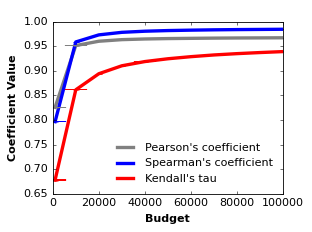

In [32]:

plt.figure(figsize=(4, 3))

plt.plot(steps, pearsons_coefficients.mean(axis=-1), color="gray", label="Pearson's coefficient", linewidth=3)
plt.plot(steps, spearman_coefficients.mean(axis=-1), color="blue", label="Spearman's coefficient", linewidth=3)
plt.plot(steps, kendall_coefficients.mean(axis=-1), color="red", label="Kendall's tau", linewidth=3)

plt.errorbar(steps, pearsons_coefficients.mean(axis=-1), pearsons_coefficients.std(axis=-1) / np.sqrt(num_runs),
  fmt="none", ecolor="gray", linewidth=20)
plt.errorbar(steps, spearman_coefficients.mean(axis=-1), spearman_coefficients.std(axis=-1) / np.sqrt(num_runs),
  fmt="none", ecolor="blue", linewidth=20)
plt.errorbar(steps, kendall_coefficients.mean(axis=-1), kendall_coefficients.std(axis=-1) / np.sqrt(num_runs),
  fmt="none", ecolor="red", linewidth=20)

print(f"Delta: {delta}, Runs: {num_runs}, Steps: {n}, Burn-in-period: {math.log(1/delta)*4*K}")
plt.title(" ")
plt.xlabel("Budget", fontweight="bold")
plt.ylabel("Coefficient Value", fontweight="bold")
plt.legend(frameon=False, loc='lower right')

plt.tight_layout()
plt.savefig(f"./outputs/exp3/small/temp_renamed_file= {filename[9:]}, runs averaged= {num_runs}, steps= {n}, delta={delta:.3f}, burn_in_period= {math.log(1/delta)*4*K:.1f}.pdf", format="pdf", dpi=1200, bbox_inches=0)
plt.show()

# Experiment 4

Not really much of an experiment, more like just plotting a histogram of the values and variances.

In [8]:
# models = ["llama-3-1-8b","gpt-4.1-nano"]
models = ["gpt-4.1-nano"]
# data_attributes = ["complexity", "correctness", "helpfulness", "verbosity"]
data_attributes = ["helpfulness"]
# models = ["llama-3-1-8b"]
# data_attributes = ["complexity"]
K = 0

histogram_version = "v1.01"

massive_rewards = []
for attribute in data_attributes:
    for model in models:
        filename = f"new_data/helpsteer2_{attribute}_{model}"
        # print(filename)

        with open("%s.jsonl" % filename, "r") as f:
          data = f.readlines()
        data = [json.loads(_) for _ in data]

        per_arm_rewards = 30  # number of per-arm random rewards
        K += len(data) // per_arm_rewards  # number of arms
        # print("Number of arms: %d" % K)

        rewards = [_["predicted_score"] for _ in data]
        # print("Percentage of invalid rewards: %.2f%%" % (100 * (rewards == -1).mean()))

        massive_rewards = massive_rewards+rewards

rewards = np.array(massive_rewards)
# raise
print("K: ", K)

random_rewards = {}
mu = np.zeros(K)
sigma = np.zeros(K)
new_K = 0
for i in range(K):
  sub_rewards = np.array(rewards[i * per_arm_rewards : (i + 1) * per_arm_rewards])
  sub_rewards = sub_rewards[sub_rewards >= 0]  # eliminate invalid rewards
  random_rewards[i] = sub_rewards
  if len(sub_rewards) == 0:
    new_K -= 1
    continue
  mu[i] = sub_rewards.mean()
  sigma[i] = np.var(sub_rewards, ddof=1)

print("new_K: ", new_K)
new_K = new_K + K
new_random_rewards = {}
new_mu = []
new_sigma = []
true_counter = 0
for i in range(K):
  if len(random_rewards[i]) != 0:
    new_random_rewards[true_counter] = random_rewards[i]
    new_mu.append(mu[i])
    new_sigma.append(sigma[i])
    true_counter += 1

K = new_K
random_rewards = new_random_rewards
mu = np.array(new_mu)
sigma = np.array(new_sigma)

print("mu.shape: ", mu.shape)
print("sigma.shape: ", sigma.shape)

K:  1017
new_K:  -1
mu.shape:  (1016,)
sigma.shape:  (1016,)


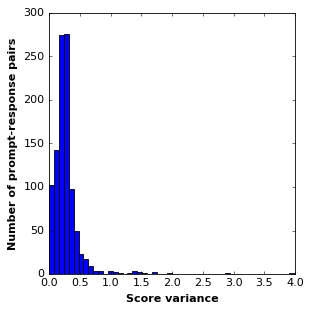

In [15]:

plt.figure(figsize=(4, 4))
plt.hist(sigma, bins=50, edgecolor='black')  # bins=10 is default, can adjust as needed
plt.xlabel('Score variance', fontweight="bold")
plt.ylabel('Number of prompt-response pairs', fontweight="bold")
plt.title('')
# plt.xticks(fontsize=12)
# plt.yticks(fontsize=12)
plt.tight_layout()
plt.savefig(f"./outputs/histograms/proper_versioning/{histogram_version},population_variance of {models[0]} on { data_attributes[0]}.pdf", format="pdf", dpi=1200, bbox_inches=0)
plt.show()

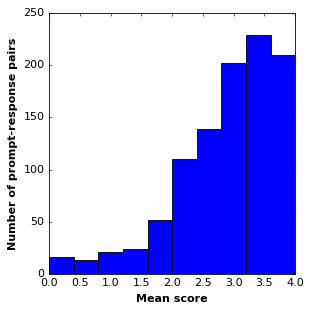

In [16]:
plt.figure(figsize=(4, 4))
plt.hist(mu, bins=10, edgecolor='black')  # bins=10 is default, can adjust as needed
plt.xlabel('Mean score', fontweight="bold")
plt.ylabel('Number of prompt-response pairs', fontweight="bold")
plt.title('')
# plt.xticks(fontsize=12)
# plt.yticks(fontsize=12)
plt.tight_layout()
plt.savefig(f"./outputs/histograms/proper_versioning/{histogram_version},mean of {models[0]} on { data_attributes[0]}.pdf", format="pdf", dpi=1200, bbox_inches=0)
plt.show()